In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

In [3]:
from scipy.stats import pearsonr

In [4]:
# url = "https://docs.google.com/spreadsheets/d/15ypLw7sjnkKBldR0nJEyZdYsHLkDDQ4n/export?format=csv"
url = "https://docs.google.com/spreadsheets/d/1Pz2T0zHJpZ2giDL7W1P-2_snsNnrqlvQ/export?format=csv"
df = pd.read_csv(url)

df

,Name,Source,Years_of_experience,Salary,Work_arrangement,Location,English_level,Skills,Job_url
0,Data Analyst,Builtin,5.0,"$40,000",Hybrid,US,NaN,"Power BI, Python, AI, Databricks, KPI, ETL, EL...",https://builtin.com/job/data-analyst/10382081
1,"Principal Data Analyst, Enterprise Data Solutions",Builtin,6.0,148K-185K Annually,Hybrid,US,NaN,"API, Python, AI, Looker Studio, LookML, SQL, S...",https://builtin.com/job/principal-data-analyst...
2,Senior Sales Data Analyst,Builtin,5.0,87K-109K Annually,Hybrid,US,NaN,"SQL, Snowflake, Looker Studio, KPI",https://builtin.com/job/senior-sales-data-anal...
3,Principal Revenue Data Analyst,Builtin,9.0,125K-200K Annually,In-Office,US,NaN,"AI, Tableau, ETL, SQL, Snowflake",https://builtin.com/job/principal-revenue-data...
4,"Staff Data Analyst, Block Compliance",Builtin,8.0,143K-258K Annually,In-Office or Remote,US,NaN,"Python, Looker Studio, ETL, Tableau, SQL",https://builtin.com/job/staff-data-analyst-blo...
...,...,...,...,...,...,...,...,...,...
844,Senior Data Analyst - Operations (m/f/x),Builtin,3.0,$73 - $84,Remote,Germany,NaN,"Looker Studio, Python, SQL, AI",https://builtin.com/job/senior-data-analyst-op...
845,Oliver Wyman - Data & Analytics Consulting - A...,Builtin,NaN,NaN,In-Office or Remote,Germany,NaN,"Python, AI",https://builtin.com/job/oliver-wyman-data-anal...
846,Senior Data Analyst (AI-Enabled Analytics) (al...,Builtin,5.0,NaN,Hybrid,Germany,NaN,"Snowflake, SQL, Metabase, AI",https://builtin.com/job/senior-data-analyst-ai...
847,Senior Data Analyst,Builtin,5.0,NaN,In-Office or Remote,Germany,NaN,"ETL, Apache Airflow, Redshift, AWS, Python, SQL",https://builtin.com/job/senior-data-analyst/88...


DATA CLEANING

In [5]:
# Dividing Work_arrangement column into 4 categories: In-Office, Remote, Hybrid, Flexible (Remote or In-Office/Hybrid)
def normalize_work_arrangement(value):
    if pd.isna(value):
        return value

    value = value.strip()

    if value in ["Office", "Office Work"]:
        return "In-Office"

    if value == "Full Remote":
        return "Remote"

    if value == "Hybrid Remote":
        return "Hybrid"

    has_office = "Office" in value
    has_remote = "Remote" in value
    has_hybrid = "Hybrid" in value

    if sum([has_office, has_remote, has_hybrid]) >= 2:
        return "Flexible (Remote or In-Office/Hybrid)"

    return value
df["Work_arrangement"] = df["Work_arrangement"].apply(normalize_work_arrangement)
# df['Work_arrangement'].unique()
# df

In [6]:
# Dividing Location column values into 5 categories: US, Poland, Germany, Ukraine, Ukraine(International) and making new column Region: US, West Europe(Germany, Poland), East Europe (Ukraine)

def normalize_Location(Location):
    if pd.isna(Location):
        return Location

    Location = Location.strip()

    if Location in ["US", "Poland", "Germany", "Ukraine"]:
        return Location

    if "Ukraine" or "Worldwide" or "EU" in Location:
        return "Ukraine(International)"

    return Location

df["Location"] = df["Location"].apply(normalize_Location)

region_mapping = {
    "US": "US",
    "Poland": "West Europe(Poland, Germany)",
    "Germany": "West Europe(Poland, Germany)",
    "Ukraine": "East Europe(Ukraine)",
    "Ukraine(International)": "East Europe(Ukraine)"
}

df["Region"] = df["Location"].map(region_mapping)

Region = df.pop("Region")
loc = df.columns.get_loc("Location")
df.insert(loc + 1, "Region", Region)

# df

In [7]:
# Making new columns Min_Salary and Max_Salary and bringing values to the same format: Annual salary in USD

df["Salary"] = (df["Salary"].str.replace(r"(?<=\d)[\s\xa0](?=\d)","",regex=True)

    .str.replace(r"\s*-\s*", "-", regex=True)

    .str.replace(r"\s+[Kk]\b", "K", regex=True)

    .str.replace(r"(\d+)K\b",r"\g<1>000",regex=True)
)

numbers = df["Salary"].str.findall(r"\d[\d,]*")

df["Min_Salary"] = numbers.str[0].str.replace(",", "").astype(float)

df["Max_Salary"] = (
    numbers.str[1]
    .fillna(numbers.str[0])
    .str.replace(",", "")
    .astype(float)
)

df["Source"] = df["Source"].str.strip()
df["Location"] = df["Location"].str.strip()

mask_builtin_poland = (
    (df["Source"] == "Builtin") &
    (df["Location"] == "Poland")
)

df.loc[mask_builtin_poland, ["Min_Salary", "Max_Salary"]] *= 1000


mask_builtin_germany = (
    (df["Source"] == "Builtin") &
    (df["Location"] == "Germany")
)

df.loc[mask_builtin_germany, ["Min_Salary", "Max_Salary"]] *= 1000

def convert_justjoin_salary(x):
    if 10 <= x <= 999:
        return x * 2080 / 3.8
    elif 1000 <= x <= 40000:
        return x * 12 / 3.8
    else:
        return x

mask_justjoin = (
    (df["Source"] == "Justjoin.it") &
    (df["Location"] == "Poland")
)

df.loc[mask_justjoin, "Min_Salary"] = (
    df.loc[mask_justjoin, "Min_Salary"]
    .apply(convert_justjoin_salary)
)

df.loc[mask_justjoin, "Max_Salary"] = (
    df.loc[mask_justjoin, "Max_Salary"]
    .apply(convert_justjoin_salary)
)

mask_djinni = df["Source"] == "Djinni"

df.loc[mask_djinni, ["Min_Salary", "Max_Salary"]] *= 12


cols = ["Min_Salary", "Max_Salary"]

df[cols] = df[cols].apply(
    lambda x: x.where(x.between(5000, 500000), None)
)

df["Years_of_experience"] = df["Years_of_experience"].where(
    df["Years_of_experience"].between(0, 15), None
)

Max_Salary = df.pop("Max_Salary")
loc = df.columns.get_loc("Salary")
df.insert(loc + 1, "Max_Salary", Max_Salary)

Min_Salary = df.pop("Min_Salary")
loc = df.columns.get_loc("Salary")
df.insert(loc + 1, "Min_Salary", Min_Salary)

df["Avg_Salary"] = df[["Min_Salary", "Max_Salary"]].mean(axis=1)

Avg_Salary = df.pop("Avg_Salary")
loc = df.columns.get_loc("Max_Salary")
df.insert(loc + 1, "Avg_Salary", Avg_Salary)

df


,Name,Source,Years_of_experience,Salary,Min_Salary,Max_Salary,Avg_Salary,Work_arrangement,Location,Region,English_level,Skills,Job_url
0,Data Analyst,Builtin,5.0,"$40,000",40000.0,40000.0,40000.0,Hybrid,US,US,NaN,"Power BI, Python, AI, Databricks, KPI, ETL, EL...",https://builtin.com/job/data-analyst/10382081
1,"Principal Data Analyst, Enterprise Data Solutions",Builtin,6.0,148000-185000 Annually,148000.0,185000.0,166500.0,Hybrid,US,US,NaN,"API, Python, AI, Looker Studio, LookML, SQL, S...",https://builtin.com/job/principal-data-analyst...
2,Senior Sales Data Analyst,Builtin,5.0,87000-109000 Annually,87000.0,109000.0,98000.0,Hybrid,US,US,NaN,"SQL, Snowflake, Looker Studio, KPI",https://builtin.com/job/senior-sales-data-anal...
3,Principal Revenue Data Analyst,Builtin,9.0,125000-200000 Annually,125000.0,200000.0,162500.0,In-Office,US,US,NaN,"AI, Tableau, ETL, SQL, Snowflake",https://builtin.com/job/principal-revenue-data...
4,"Staff Data Analyst, Block Compliance",Builtin,8.0,143000-258000 Annually,143000.0,258000.0,200500.0,Flexible (Remote or In-Office/Hybrid),US,US,NaN,"Python, Looker Studio, ETL, Tableau, SQL",https://builtin.com/job/staff-data-analyst-blo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
844,Senior Data Analyst - Operations (m/f/x),Builtin,3.0,$73-$84,73000.0,84000.0,78500.0,Remote,Germany,"West Europe(Poland, Germany)",NaN,"Looker Studio, Python, SQL, AI",https://builtin.com/job/senior-data-analyst-op...
845,Oliver Wyman - Data & Analytics Consulting - A...,Builtin,NaN,NaN,NaN,NaN,NaN,Flexible (Remote or In-Office/Hybrid),Germany,"West Europe(Poland, Germany)",NaN,"Python, AI",https://builtin.com/job/oliver-wyman-data-anal...
846,Senior Data Analyst (AI-Enabled Analytics) (al...,Builtin,5.0,NaN,NaN,NaN,NaN,Hybrid,Germany,"West Europe(Poland, Germany)",NaN,"Snowflake, SQL, Metabase, AI",https://builtin.com/job/senior-data-analyst-ai...
847,Senior Data Analyst,Builtin,5.0,NaN,NaN,NaN,NaN,Flexible (Remote or In-Office/Hybrid),Germany,"West Europe(Poland, Germany)",NaN,"ETL, Apache Airflow, Redshift, AWS, Python, SQL",https://builtin.com/job/senior-data-analyst/88...


Dataset Overview

In [8]:
# Number of vacancies by Location
df["Location"].value_counts()

,count
Location,
US,324
Poland,290
Ukraine(International),130
Ukraine,69
Germany,36


In [9]:
# Number of vacancies by Source
df["Source"].value_counts()

,count
Source,
Builtin,450
Justjoin.it,200
Djinni,199


In [10]:
# Number of vacancies by Work arrangement type
df["Work_arrangement"].value_counts()

,count
Work_arrangement,
Remote,272
In-Office,264
Hybrid,212
Flexible (Remote or In-Office/Hybrid),101


In [11]:
# None values
'''
None values in Dataset show that:
≈ 26% of hiring companies do not require or specify number of experience years needed
≈ 25% of hiring companies do not specify their offered salary range
≈ 64% of hiring companies do not specify the required English level, most likely implying that candidates should be fluent in English (approximately C1 level)
≈ 6% of hiring companies do not specify any common hard skills for Data Analytics
'''

df_None_values = (df.isna().mean() * 100).round(2).reset_index()

df_None_values.columns = ["Column", "None_values_%"]

df_None_values

,Column,None_values_%
0,Name,0.00
1,Source,0.00
2,Years_of_experience,26.27
3,Salary,25.21
4,Min_Salary,26.62
5,Max_Salary,26.74
6,Avg_Salary,26.38
7,Work_arrangement,0.00
8,Location,0.00
9,Region,0.00


In [12]:
# Geography
# Min&Max salary range difference by region (note: highly dependent on number of junior(low-paid) or senior(high-paid) vacancies)
df_salary_by_region = df.groupby("Region")[["Min_Salary", "Max_Salary","Avg_Salary"]].mean().round(2)
df_salary_by_region

,Min_Salary,Max_Salary,Avg_Salary
Region,,,
East Europe(Ukraine),20360.80,32550.75,26455.78
US,95586.67,139203.33,117395.00
"West Europe(Poland, Germany)",73713.81,89008.25,82498.21


EDA

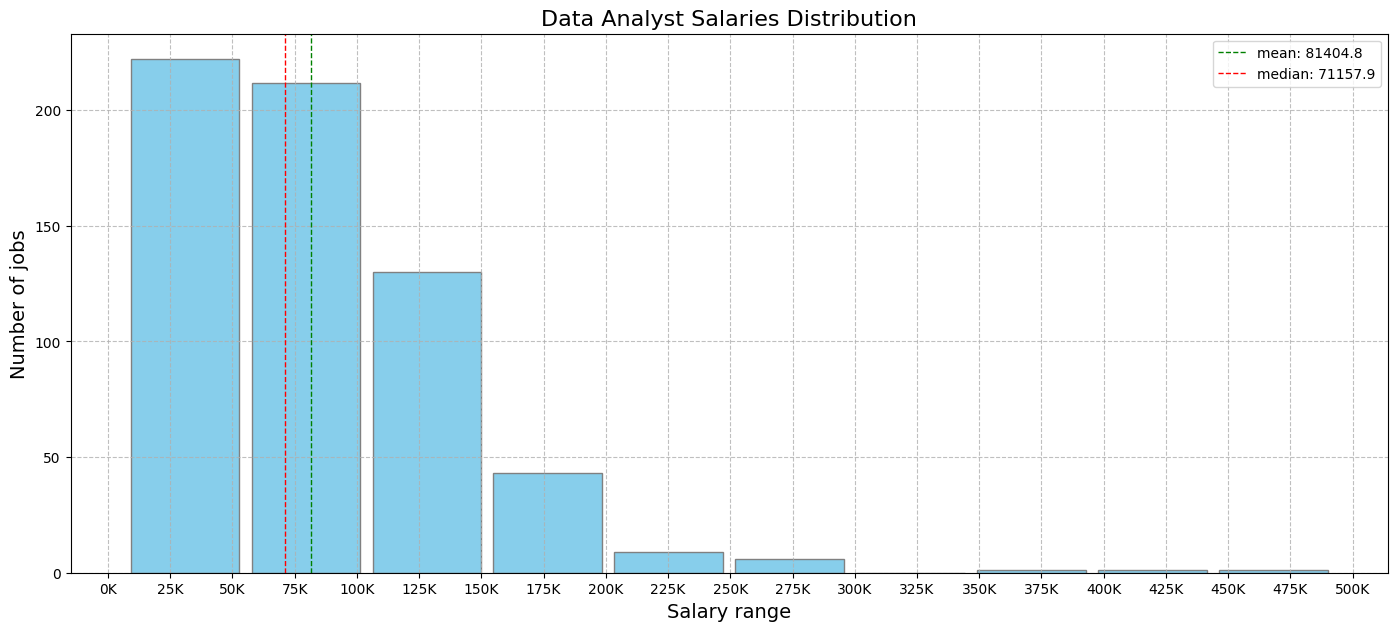

In [13]:
# sns.histplot(df["Avg_Salary"].dropna(), kde=True)

plt.figure(figsize=(17, 7))
plt.hist(df["Avg_Salary"], bins=10, color='skyblue',  edgecolor='grey', linewidth=1,rwidth=0.9)
plt.title("Data Analyst Salaries Distribution", fontsize=16)
plt.xlabel("Salary range", fontsize=14)
plt.ylabel("Number of jobs", fontsize=14)

plt.axvline(df["Avg_Salary"].mean(), color='g', linestyle='--', linewidth=1, label="mean: {:.1f}".format(df["Avg_Salary"].mean()))
plt.axvline(df["Avg_Salary"].median(), color='r', linestyle='dashed', linewidth=1,label="median: {:.1f}".format(df["Avg_Salary"].median()))

plt.xticks(np.arange(0, 500001, 25000))

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x/1000)}K')
)

plt.grid(True, linestyle='--', alpha=0.8)
# plt.xlim(0, 500000)
plt.legend()
plt.show()


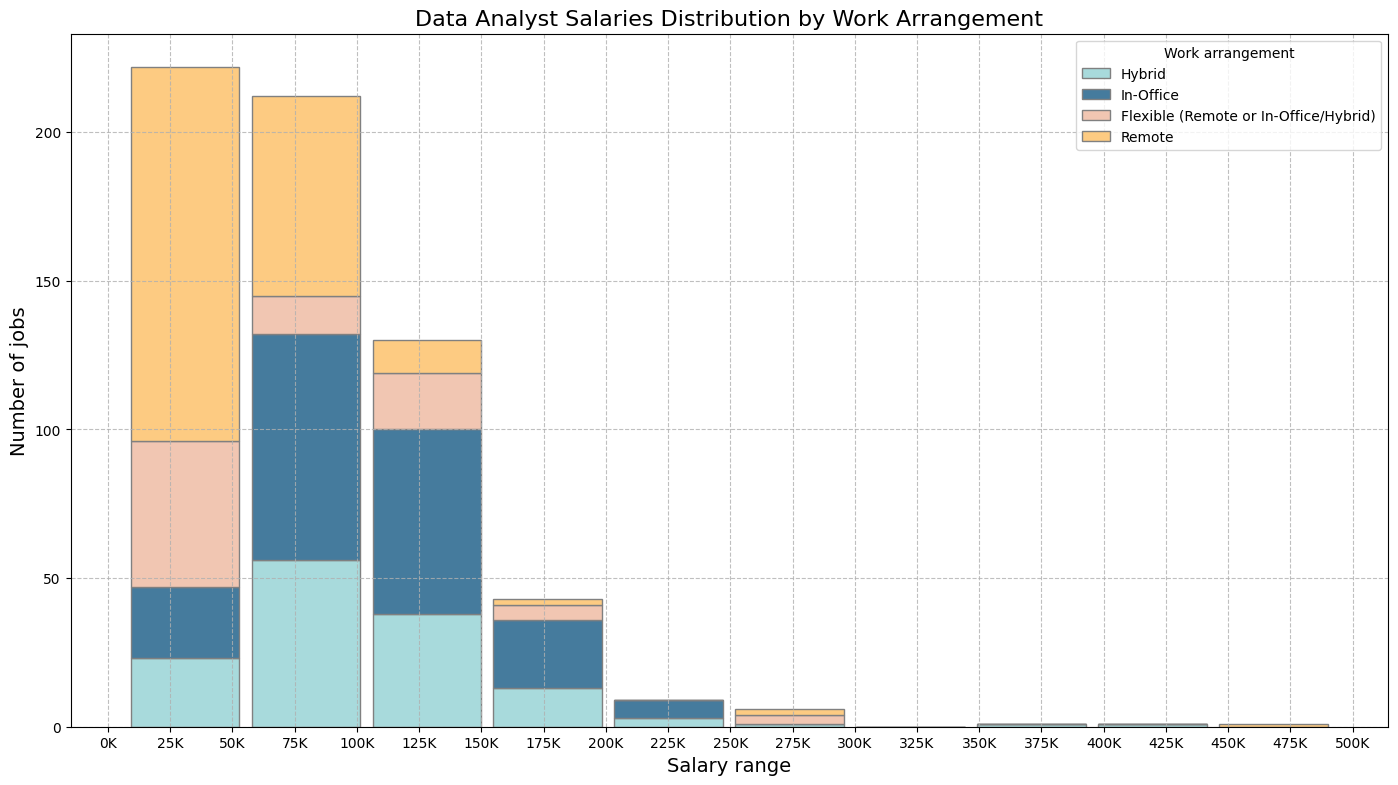

In [14]:
plt.figure(figsize=(17, 9))

colors = ['#A8DADC','#457B9D','#F1C6B2','#FDCB82']
#E63946','#F1A7B4','#B7E4C7','#6A994E','#F4A261','#2A9D8F']

work_types = df["Work_arrangement"].dropna().unique()

data = [
    df.loc[df["Work_arrangement"] == work_type, "Avg_Salary"].dropna()
    for work_type in work_types
]

plt.hist(
    data,
    bins=10,
    stacked=True,
    color=colors,
    edgecolor="grey",
    linewidth=1,
    rwidth=0.9,
    label=work_types
)

plt.title("Data Analyst Salaries Distribution by Work Arrangement", fontsize=16)
plt.xlabel("Salary range", fontsize=14)
plt.ylabel("Number of jobs", fontsize=14)

plt.xticks(np.arange(0, 500001, 25000))

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x/1000)}K')
)

plt.grid(True, linestyle='--', alpha=0.8)
plt.legend(title="Work arrangement")

plt.show()


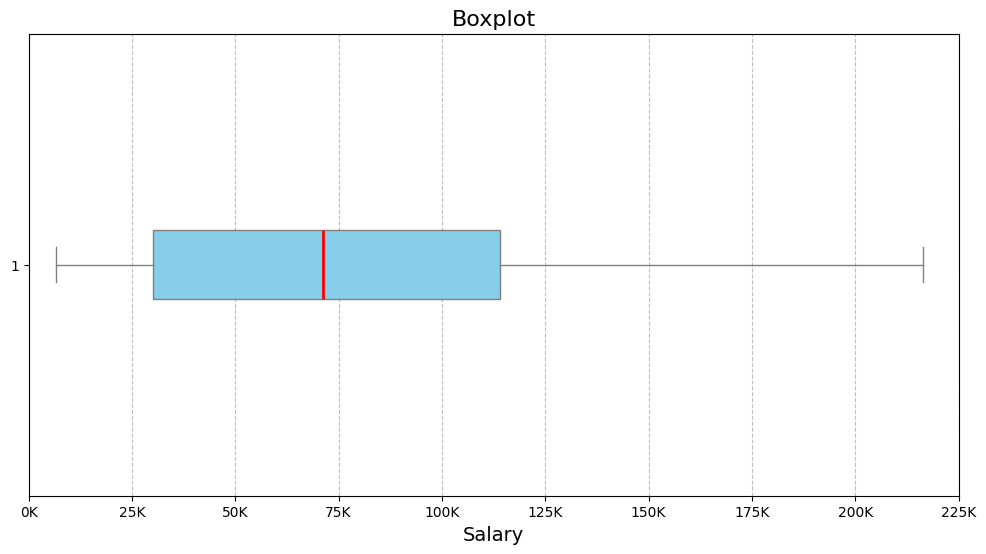

In [15]:
plt.figure(figsize=(12, 6))

plt.boxplot(
    df["Avg_Salary"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='grey'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='grey'),
    capprops=dict(color='grey'),
    flierprops=dict(
        marker='o',
        markerfacecolor='grey',
        markersize=5,
        markeredgecolor='grey'
    )
)
plt.xlim(0, 225000)
plt.title("Boxplot", fontsize=16)
plt.xlabel("Salary", fontsize=14)


plt.xticks(np.arange(0, 250000, 25000))

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x/1000)}K')
)

plt.grid(True, axis='x', linestyle='--', alpha=0.8)

plt.show()

<Figure size 1800x800 with 0 Axes>

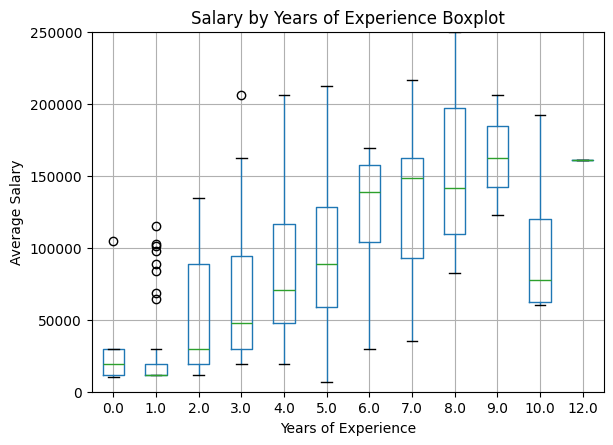

In [16]:
plt.figure(figsize=(18, 8))

df.boxplot(
    column="Avg_Salary",
    by="Years_of_experience"
)

plt.title("Salary by Years of Experience Boxplot")
plt.suptitle("")
plt.xlabel("Years of Experience")
plt.ylabel("Average Salary")

plt.ylim(0, 250000)

plt.show()

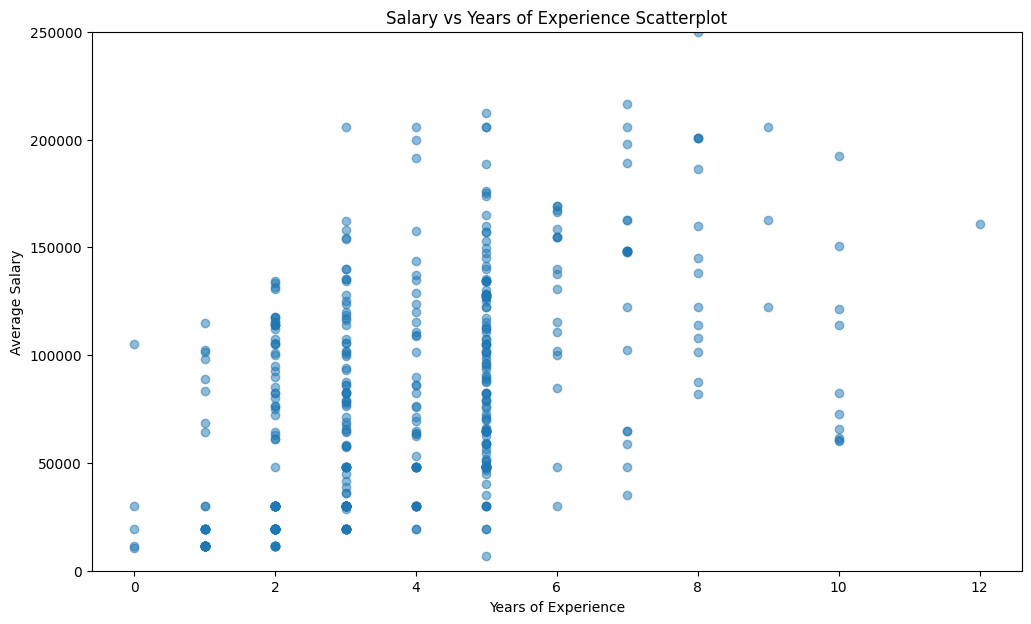

In [17]:
plt.figure(figsize=(12, 7))

plt.scatter(
    df["Years_of_experience"],
    df["Avg_Salary"],
    alpha=0.5
)

plt.title("Salary vs Years of Experience Scatterplot")
plt.xlabel("Years of Experience")
plt.ylabel("Average Salary")

plt.ylim(0, 250000)

plt.show()

In [18]:
df['Skills_Count'] = df['Skills'].str.split(',').str.len()

Skills_Count = df.pop("Skills_Count")
loc = df.columns.get_loc("Skills")
df.insert(loc + 1, "Skills_Count", Skills_Count)

df['Skills_count'] = df['Skills'].fillna('').str.split(',').str.len()

df

,Name,Source,Years_of_experience,Salary,Min_Salary,Max_Salary,Avg_Salary,Work_arrangement,Location,Region,English_level,Skills,Skills_Count,Job_url,Skills_count
0,Data Analyst,Builtin,5.0,"$40,000",40000.0,40000.0,40000.0,Hybrid,US,US,NaN,"Power BI, Python, AI, Databricks, KPI, ETL, EL...",9.0,https://builtin.com/job/data-analyst/10382081,9
1,"Principal Data Analyst, Enterprise Data Solutions",Builtin,6.0,148000-185000 Annually,148000.0,185000.0,166500.0,Hybrid,US,US,NaN,"API, Python, AI, Looker Studio, LookML, SQL, S...",7.0,https://builtin.com/job/principal-data-analyst...,7
2,Senior Sales Data Analyst,Builtin,5.0,87000-109000 Annually,87000.0,109000.0,98000.0,Hybrid,US,US,NaN,"SQL, Snowflake, Looker Studio, KPI",4.0,https://builtin.com/job/senior-sales-data-anal...,4
3,Principal Revenue Data Analyst,Builtin,9.0,125000-200000 Annually,125000.0,200000.0,162500.0,In-Office,US,US,NaN,"AI, Tableau, ETL, SQL, Snowflake",5.0,https://builtin.com/job/principal-revenue-data...,5
4,"Staff Data Analyst, Block Compliance",Builtin,8.0,143000-258000 Annually,143000.0,258000.0,200500.0,Flexible (Remote or In-Office/Hybrid),US,US,NaN,"Python, Looker Studio, ETL, Tableau, SQL",5.0,https://builtin.com/job/staff-data-analyst-blo...,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844,Senior Data Analyst - Operations (m/f/x),Builtin,3.0,$73-$84,73000.0,84000.0,78500.0,Remote,Germany,"West Europe(Poland, Germany)",NaN,"Looker Studio, Python, SQL, AI",4.0,https://builtin.com/job/senior-data-analyst-op...,4
845,Oliver Wyman - Data & Analytics Consulting - A...,Builtin,NaN,NaN,NaN,NaN,NaN,Flexible (Remote or In-Office/Hybrid),Germany,"West Europe(Poland, Germany)",NaN,"Python, AI",2.0,https://builtin.com/job/oliver-wyman-data-anal...,2
846,Senior Data Analyst (AI-Enabled Analytics) (al...,Builtin,5.0,NaN,NaN,NaN,NaN,Hybrid,Germany,"West Europe(Poland, Germany)",NaN,"Snowflake, SQL, Metabase, AI",4.0,https://builtin.com/job/senior-data-analyst-ai...,4
847,Senior Data Analyst,Builtin,5.0,NaN,NaN,NaN,NaN,Flexible (Remote or In-Office/Hybrid),Germany,"West Europe(Poland, Germany)",NaN,"ETL, Apache Airflow, Redshift, AWS, Python, SQL",6.0,https://builtin.com/job/senior-data-analyst/88...,6


In [19]:
df_numeric = df.select_dtypes(include="number")
df_numeric = df[[
    "Years_of_experience",
    "Avg_Salary",
    "Skills_Count"
]]
corr_matrix = df_numeric.corr(numeric_only=True)
corr_matrix

,Years_of_experience,Avg_Salary,Skills_Count
Years_of_experience,1.000000,0.461140,-0.005047
Avg_Salary,0.461140,1.000000,-0.005598
Skills_Count,-0.005047,-0.005598,1.000000


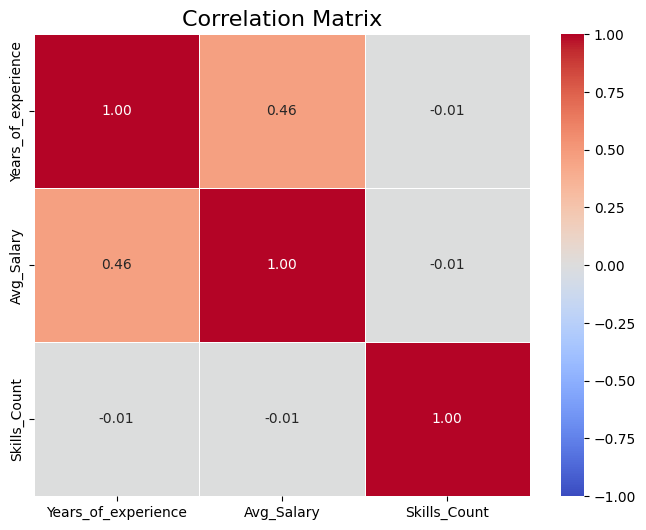

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=16)
plt.show()

In [21]:
#  The correlation between Salary and Number of Skills in vacancies
corr_df = df[['Skills_count', 'Avg_Salary']].dropna()

corr_df.head()

r, p_value = pearsonr(
    corr_df['Skills_count'],
    corr_df['Avg_Salary']
)

print(f"Pearson correlation (r): {r:.3f}")
print(f"p-value: {p_value:.5f}")

# There is virtually no linear association between the number of required skills and average salary (Pearson r = -0.004, p = 0.915).
# The correlation is not statistically significant, suggesting that the number of skills listed in a Data Analyst job posting is not meaningfully associated with salary in this dataset.


Pearson correlation (r): -0.004
p-value: 0.91487


In [22]:
#  The correlation between Salary and years of experience required
corr_df = df[['Years_of_experience', 'Avg_Salary']].dropna()

corr_df.head()

r, p_value = pearsonr(
    corr_df['Years_of_experience'],
    corr_df['Avg_Salary']
)

print(f"Pearson correlation (r): {r:.3f}")
print(f"p-value: {p_value:.5f}")

# There is a strong linear association(Pearson r = 0.461, p = 0): Years o experience is an important factor, however it  does not explain the entire variation in salaries.

Pearson correlation (r): 0.461
p-value: 0.00000


In [23]:
# Which skills are associated with higher-paying Data Analyst jobs, and which skills are more common in lower-paying jobs?

In [24]:
salary_median = df['Avg_Salary'].median()

df['Salary_group'] = df['Avg_Salary'].apply(
    lambda x: 'High Salary' if x >= salary_median else 'Low Salary'
)


skills_df = df[['Avg_Salary', 'Salary_group', 'Skills']].dropna().copy()

skills_df['Skills'] = skills_df['Skills'].str.split(',')

skills_df = skills_df.explode('Skills')

skills_df['Skills'] = skills_df['Skills'].str.strip()


skill_salary = (
    skills_df
    .groupby(['Salary_group', 'Skills'])
    .size()
    .reset_index(name='count')
)

group_sizes = df['Salary_group'].value_counts()

skill_salary['percentage'] = skill_salary.apply(
    lambda row: row['count'] / group_sizes[row['Salary_group']] * 100,
    axis=1
)


high_salary_skills = (
    skill_salary[skill_salary['Salary_group'] == 'High Salary']
    .sort_values('percentage', ascending=False)
)

high_salary_skills.head(15)

,Salary_group,Skills,count,percentage
32,High Salary,SQL,240,76.190476
30,High Salary,Python,183,58.095238
1,High Salary,AI,119,37.777778
37,High Salary,Tableau,108,34.285714
27,High Salary,Power BI,102,32.380952
12,High Salary,Excel,85,26.984127
35,High Salary,Snowflake,60,19.047619
19,High Salary,KPI,50,15.873016
3,High Salary,AWS,45,14.285714
11,High Salary,ETL,41,13.015873


In [25]:
# 76% of higher-paid Data Analyst job offers require SQL, 58% - Python, 37% - mention AI, 34% - Tableua, 32% - Power BI...

In [26]:
skill_comparison = (
    skill_salary
    .pivot(index='Skills', columns='Salary_group', values='percentage')
    .fillna(0)
)

skill_comparison['difference'] = (
    skill_comparison['High Salary']
    - skill_comparison['Low Salary']
)

skill_comparison.sort_values(
    'difference',
    ascending=False
)

skill_comparison.sort_values(
    'difference',
    ascending=False
).head(15)



Salary_group,High Salary,Low Salary,difference
Skills,,,
SQL,76.190476,39.700375,36.490102
Python,58.095238,23.970037,34.125201
AI,37.777778,17.790262,19.987516
Tableau,34.285714,19.662921,14.622793
Snowflake,19.047619,5.617978,13.429642
AWS,14.285714,2.247191,12.038523
Databricks,12.063492,2.621723,9.441769
Excel,26.984127,17.790262,9.193865
Spark,11.428571,2.808989,8.619583


In [27]:
# df.to_excel("people.xlsx", index=False)

# from google.colab import files

# files.download("people.xlsx")

In [28]:
# Job vacancies parsing:
# (Builtin website example)

In [29]:
# making xlsx file:

